Using device: cpu
Training samples : 60000
Test samples     : 10000
Autoencoder(
  (encoder): Encoder(
    (block1): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (block2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (block3): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (decoder): Decoder(
    (block1): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

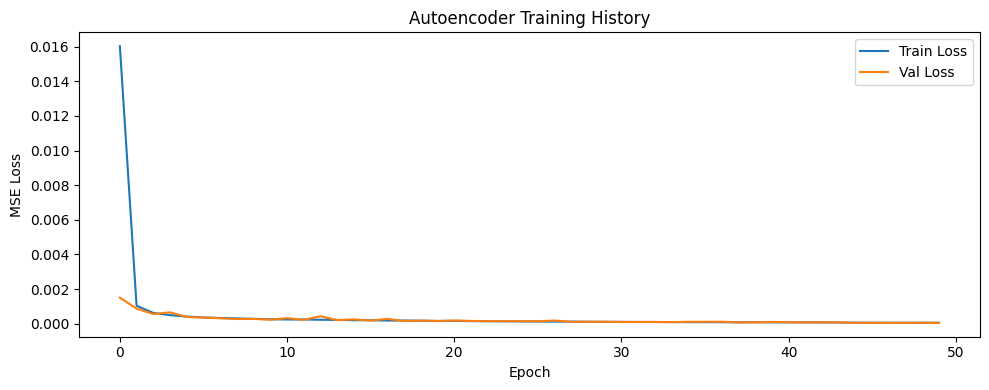

Saved: training_history.png


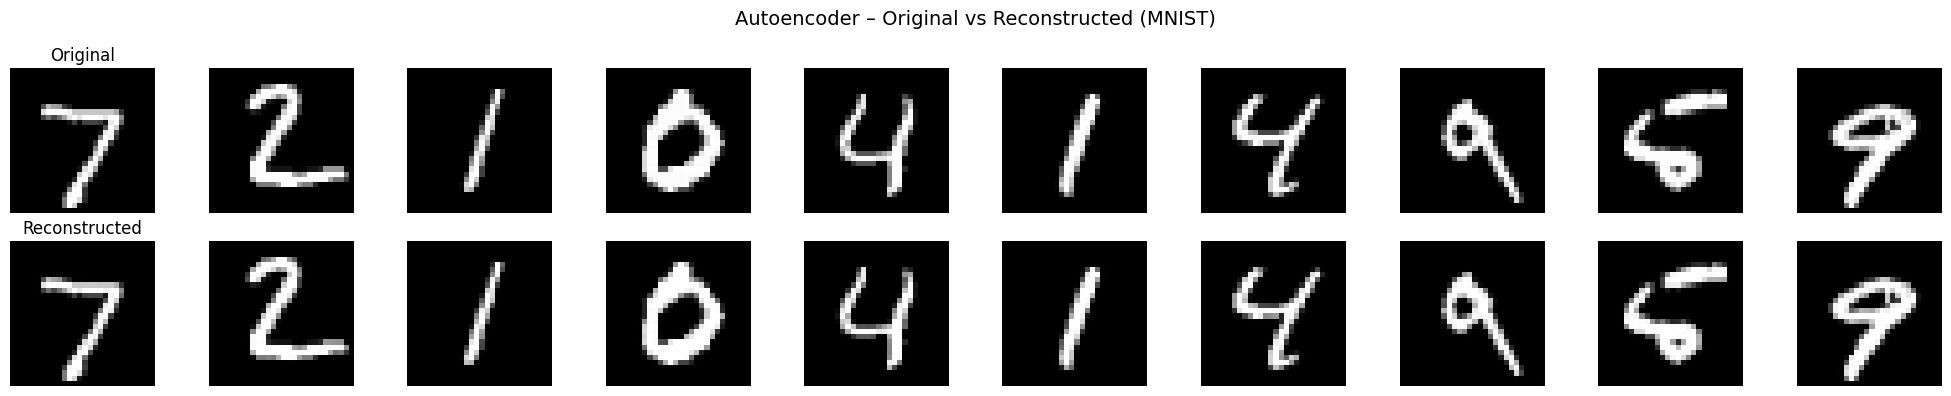

Saved: reconstruction_results.png


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────
# Device Configuration
# ─────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ─────────────────────────────────────────
# Load Dataset
# ─────────────────────────────────────────
# Normalize pixel values to [0, 1]
transform = transforms.Compose([
    transforms.ToTensor()   # Converts PIL image to tensor and scales to [0, 1]
])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

# ─────────────────────────────────────────
# Define the Improved Autoencoder Model
# ─────────────────────────────────────────
# TASK – Improve the Model
# Improvements over the baseline:
#   1. Deeper encoder with 3 Conv blocks (32 → 64 → 128 filters)
#   2. Batch Normalization after every Conv layer for stable training
#   3. Decoder mirrors the encoder using ConvTranspose2d (learned upsampling)
#      instead of UpSampling2D + Conv (better spatial reconstruction)
#   4. Bottleneck kept at 7×7×128 ≈ 6 272 values, giving a richer latent space

class Encoder(nn.Module):
    """Compresses 28×28×1 input into a latent representation."""

    def __init__(self):
        super().__init__()
        # Block 1 – 28×28×1  → 14×14×32
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # stride-2 replaces MaxPool
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        # Block 2 – 14×14×32 → 7×7×64
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        # Block 3 – 7×7×64  → 7×7×128  (no spatial downsampling, richer features)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x   # shape: (B, 128, 7, 7)


class Decoder(nn.Module):
    """Reconstructs the original image from the latent representation."""

    def __init__(self):
        super().__init__()
        # Block 1 – 7×7×128 → 7×7×64
        self.block1 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        # Block 2 – 7×7×64  → 14×14×32
        self.block2 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        # Block 3 – 14×14×32 → 28×28×1  (output layer uses Sigmoid to keep values in [0,1])
        self.block3 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x   # shape: (B, 1, 28, 28)


class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed


# Instantiate model and move to device
autoencoder = Autoencoder().to(device)
print(autoencoder)

# Count total trainable parameters
total_params = sum(p.numel() for p in autoencoder.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

# ─────────────────────────────────────────
# Compile / Configure Training
# ─────────────────────────────────────────
criterion = nn.MSELoss()                         # Reconstruction loss
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)

# Learning-rate scheduler: halve LR if val loss doesn't improve for 5 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                  patience=5, factor=0.5)

# ─────────────────────────────────────────
# Train the Autoencoder
# ─────────────────────────────────────────
EPOCHS = 50
train_losses = []
val_losses   = []

print("\nStarting training …")
for epoch in range(1, EPOCHS + 1):

    # ── Training phase ──────────────────
    autoencoder.train()
    running_loss = 0.0
    for images, _ in train_loader:      # labels are unused (unsupervised task)
        images = images.to(device)

        optimizer.zero_grad()
        outputs = autoencoder(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # ── Validation phase ─────────────────
    autoencoder.eval()
    running_val = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = autoencoder(images)
            running_val += criterion(outputs, images).item() * images.size(0)

    val_loss = running_val / len(test_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:>2}/{EPOCHS}]  "
              f"Train Loss: {train_loss:.6f}  |  Val Loss: {val_loss:.6f}")

print("Training complete.")

# ─────────────────────────────────────────
# Plot Training & Validation Loss
# ─────────────────────────────────────────
try:
    plt.figure(figsize=(10, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses,   label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Autoencoder Training History")
    plt.legend()
    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    plt.show()
    print("Saved: training_history.png")
except Exception as e:
    print(f"Error during plotting training history: {e}")

# ─────────────────────────────────────────
# Visualize the Results
# ─────────────────────────────────────────
try:
    # Compare original vs. reconstructed images for n test samples
    autoencoder.eval()
    n = 10   # number of digits to display

    # Grab one batch from the test loader
    test_images, _ = next(iter(test_loader))
    test_images = test_images[:n].to(device)

    with torch.no_grad():
        reconstructed = autoencoder(test_images)

    # Move back to CPU for plotting
    originals      = test_images.cpu().numpy()
    reconstructions = reconstructed.cpu().numpy()

    fig, axes = plt.subplots(2, n, figsize=(20, 4))
    for i in range(n):
        # Original
        ax = axes[0, i]
        ax.imshow(originals[i].reshape(28, 28), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title("Original", fontsize=12)

        # Reconstructed
        ax = axes[1, i]
        ax.imshow(reconstructions[i].reshape(28, 28), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title("Reconstructed", fontsize=12)

    plt.suptitle("Autoencoder – Original vs Reconstructed (MNIST)", fontsize=14)
    plt.tight_layout()
    plt.savefig("reconstruction_results.png", dpi=150)
    plt.show()
    print("Saved: reconstruction_results.png")
except Exception as e:
    print(f"Error during visualizing results: {e}")